In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, GridSearchCV
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss

In [2]:
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('/content/drive/MyDrive/data for Machine learning training/data label 30 seconds frequency.csv')

In [4]:
df.head()

,timestamp,devID,soil_mean,rain_mean,temp_mean,humi_mean,geo_mean,hour,label
0,5/2/2025 12:00,101,28.766666,0.0,35.233590,61.564409,14.308251,12,NaN
1,5/2/2025 12:00,101,28.799999,0.0,35.331501,62.408737,15.891333,12,NaN
2,5/2/2025 12:01,101,28.799999,0.0,35.379566,61.602236,14.088287,12,NaN
3,5/2/2025 12:01,101,28.766666,0.0,35.430302,63.564610,15.119175,12,NaN
4,5/2/2025 12:02,101,28.766666,0.0,35.508638,64.492868,14.641307,12,NaN


In [5]:
df['label'] = df['label'].fillna('normal')

In [6]:
print(df)

           timestamp  devID  soil_mean  rain_mean  temp_mean  humi_mean  \
0     5/2/2025 12:00    101  28.766666        0.0  35.233590  61.564409   
1     5/2/2025 12:00    101  28.799999        0.0  35.331501  62.408737   
2     5/2/2025 12:01    101  28.799999        0.0  35.379566  61.602236   
3     5/2/2025 12:01    101  28.766666        0.0  35.430302  63.564610   
4     5/2/2025 12:02    101  28.766666        0.0  35.508638  64.492868   
...              ...    ...        ...        ...        ...        ...   
4881  5/4/2025 11:55    101  48.366667        0.0  33.772026  69.169754   
4882  5/4/2025 11:56    101  48.400002        0.0  33.766685  69.380520   
4883  5/4/2025 11:57    101  48.400002        0.0  33.756004  67.130768   
4884  5/4/2025 11:57    101  48.350000        0.0  33.789387  68.244675   
4885  5/4/2025 11:58    101  48.350000        0.0  33.734642  67.111694   

       geo_mean  hour   label  
0     14.308251    12  normal  
1     15.891333    12  normal  
2  

In [7]:
feature_column=['soil_mean','rain_mean','temp_mean','humi_mean','geo_mean',]
target_column='label'
x=df[feature_column]
y=df[target_column]

In [8]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
print(f"\nData split complete")
print(f"Training set has {X_train.shape[0]} samples")
print(f"Testing set has {X_test.shape[0]} samples")
print("\nTraining set label distribution:")
print(y_train.value_counts())


Data split complete
Training set has 3908 samples
Testing set has 978 samples

Training set label distribution:
label
normal      3695
warning      150
critical      63
Name: count, dtype: int64


In [10]:
import joblib

model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Training the model... ⏳")
model.fit(X_train, y_train)
print("Model training complete! ✅")



Training the model... ⏳
Model training complete! ✅


In [11]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n--- Model Performance Metrics ---")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


--- Model Performance Metrics ---
Accuracy: 0.998
Precision: 0.998
Recall: 0.998
F1 Score: 0.998
Classification Report:
               precision    recall  f1-score   support

    critical       1.00      1.00      1.00        16
      normal       1.00      1.00      1.00       924
     warning       0.95      1.00      0.97        38

    accuracy                           1.00       978
   macro avg       0.98      1.00      0.99       978
weighted avg       1.00      1.00      1.00       978



In [12]:
# Assuming y_pred_proba has columns corresponding to the order of labels in model.classes_
# You need to know the order of classes in your model to correctly access probabilities

# Get the index of 'warning' and 'critical' classes
warning_index = list(model.classes_).index('warning')
critical_index = list(model.classes_).index('critical')

# Check if the probability of 'warning' or 'critical' is greater than 0.8 for any sample
# This will return a boolean array
is_anomaly = (y_pred_proba[:, warning_index] > 0.8) | (y_pred_proba[:, critical_index] > 0.8)

# If there is at least one sample predicted as anomaly with probability > 0.8, trigger the alert
if is_anomaly.any():
    # Replace with your actual alert triggering mechanism
    print("Alert: Potential landslide detected!")
    # trigger_alert() # Uncomment this line if you have a trigger_alert function defined
else:
    print("No anomaly detected with probability > 0.8")

Alert: Potential landslide detected!


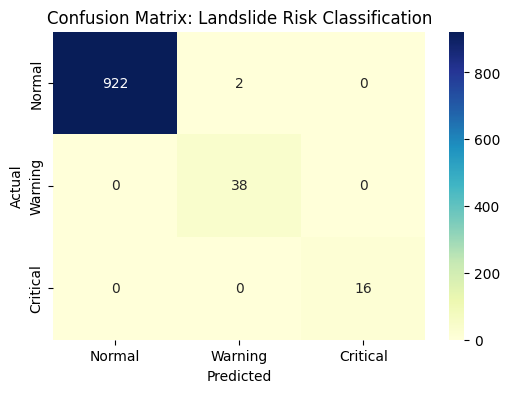

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=['normal','warning','critical'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Normal", "Warning", "Critical"],
            yticklabels=["Normal", "Warning", "Critical"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Landslide Risk Classification")
plt.show()

In [14]:
# Load the saved model
loaded_model_path = '/content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib'
loaded_model = joblib.load(loaded_model_path)

print(f"Model loaded from {loaded_model_path}")

# --- Example Inference ---
# Assuming you have new data in a pandas DataFrame called 'new_data_df'
# The new data should have the same columns as the training features: 'soil_mean','rain_mean','temp_mean','humi_mean','geo_mean'

# Create some dummy new data for demonstration purposes
# In a real scenario, you would load your actual new data here
new_data = {
    'soil_mean': [100.0, 45.0, 100.0],
    'rain_mean': [11, 5.0, 50],
    'temp_mean': [25, 30.0, 24],
    'humi_mean': [60.0, 70.0, 95.0],
    'geo_mean': [19.0, 10.0, 20.0]
}
new_data_df = pd.DataFrame(new_data)
print("\nNew data for inference:")
display(new_data_df)

# Scale the new data using the *same* scaler fitted on the training data
# Make sure the 'scaler' object from the training phase is available
new_data_scaled = scaler.transform(new_data_df)

# Make predictions
predictions = loaded_model.predict(new_data_scaled)
predictions_proba = loaded_model.predict_proba(new_data_scaled)

print("\nInference Results:")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Predicted Label = {pred}, Prediction Probabilities = {predictions_proba[i]}")

Model loaded from /content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib

New data for inference:


,soil_mean,rain_mean,temp_mean,humi_mean,geo_mean
0,100.0,11.0,25.0,60.0,19.0
1,45.0,5.0,30.0,70.0,10.0
2,100.0,50.0,24.0,95.0,20.0



Inference Results:
Sample 1: Predicted Label = critical, Prediction Probabilities = [0.67 0.02 0.31]
Sample 2: Predicted Label = warning, Prediction Probabilities = [0.01 0.13 0.86]
Sample 3: Predicted Label = critical, Prediction Probabilities = [0.95 0.03 0.02]


In [15]:
loaded_model_path = '/content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib'
loaded_model = joblib.load(loaded_model_path)

print(f"Model loaded from {loaded_model_path}")


Model loaded from /content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib


In [16]:
new_data_ =pd.read_csv("/content/drive/MyDrive/Isolation forest data/merge_data_flex_t.csv")
new_data_df1 = pd.DataFrame(new_data_)
print("\nNew data for inference:")
display(new_data_df)


New data for inference:


,soil_mean,rain_mean,temp_mean,humi_mean,geo_mean
0,100.0,11.0,25.0,60.0,19.0
1,45.0,5.0,30.0,70.0,10.0
2,100.0,50.0,24.0,95.0,20.0



--- Performance Metrics on New Data (new_data_df1) ---
Accuracy: 0.998
Precision: 0.998
Recall: 0.998
F1 Score: 0.998
Classification Report:
               precision    recall  f1-score   support

    critical       0.95      0.91      0.93        22
      normal       1.00      1.00      1.00      6415
     warning       0.96      0.89      0.93        84

    accuracy                           1.00      6521
   macro avg       0.97      0.93      0.95      6521
weighted avg       1.00      1.00      1.00      6521



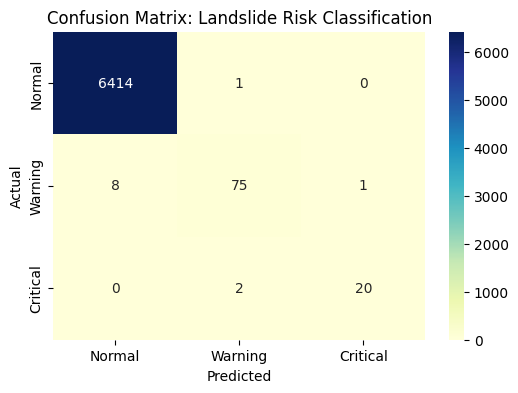

In [17]:
# Fill missing values in the 'label' column with 'normal'
new_data_df1['label'] = new_data_df1['label'].fillna('normal')

# Use the 'label' column from new_data_df1 as the true labels for evaluation
y_true_new1 = new_data_df1['label']

# Scale the new data (new_data_df1) using the same scaler fitted on the training data
# Make sure the 'scaler' object from the training phase is available
new_data_scaled1 = scaler.transform(new_data_df1[feature_column])

# Make predictions on the scaled new data (new_data_df1)
y_pred_new1 = loaded_model.predict(new_data_scaled1)

# Calculate and display performance metrics
accuracy_new1 = accuracy_score(y_true_new1, y_pred_new1)
precision_new1 = precision_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
recall_new1 = recall_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
f1_new1 = f1_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
cm_new1 = confusion_matrix(y_true_new1, y_pred_new1, labels=['normal', 'warning', 'critical'])


print("\n--- Performance Metrics on New Data (new_data_df1) ---")
print("Accuracy:", round(accuracy_new1, 3))
print("Precision:", round(precision_new1, 3))
print("Recall:", round(recall_new1, 3))
print("F1 Score:", round(f1_new1, 3))
print("Classification Report:\n", classification_report(y_true_new1, y_pred_new1, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_new1, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Normal", "Warning", "Critical"],
            yticklabels=["Normal", "Warning", "Critical"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Landslide Risk Classification")
plt.show()

/tmp/ipython-input-1521407157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='viridis')


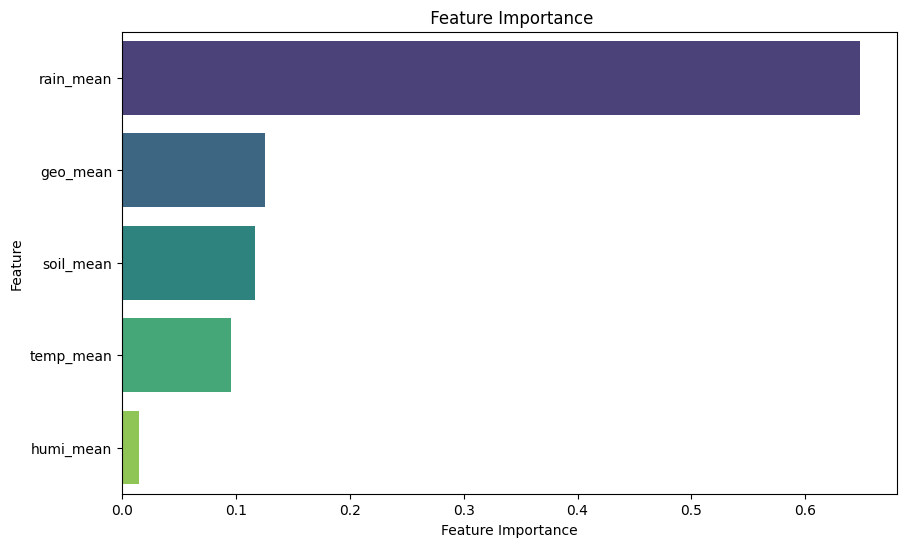

In [18]:
# Get feature importances
feature_importances = loaded_model.feature_importances_

# Create a pandas Series for easier visualization
feature_importances_series = pd.Series(feature_importances, index=feature_column)

# Sort the features by importance
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(' Feature Importance')
plt.show()